# How has collaboration in scientific research changed across arXiv fields over time? 

## 2. Has the amount of cross-field collaboration increased over time?
See if research increasingly connects different arXiv fields over time.

For the initial analysis, we will use arXiv category cross-listings as a proxy for cross-field research. A paper will be considered cross-field when its categories represent more than one broad research field.

This gives us a feasible starting point before attempting the more computationally expensive author-history and embedding approach.



## Set Up File Paths

The cleaned CSV is in `data/processed`. If it is missing, incomplete, or uses older sampling settings, the notebook rebuilds it from the raw arXiv metadata using the cleaning script in `scripts`.


In [1]:
from pathlib import Path
import sys


def find_project_root(start=Path.cwd()):
    for folder in [start, *start.parents]:
        if (folder / "data").exists() and (folder / "scripts").exists():
            return folder
    raise FileNotFoundError("Could not find the project folder with data/ and scripts/.")


PROJECT_ROOT = find_project_root()
RAW_FILE = PROJECT_ROOT / "data" / "raw" / "arxiv-metadata-oai-snapshot.zip"
CLEAN_FILE = PROJECT_ROOT / "data" / "processed" / "arxiv_metadata_clean.csv"
SCRIPTS_DIR = PROJECT_ROOT / "scripts"

if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

print(f"Project folder: {PROJECT_ROOT}")
print(f"Clean data file: {CLEAN_FILE}")

Project folder: c:\Users\tanoa\OneDrive\Documents\GitHub\applied_ds_capstone
Clean data file: c:\Users\tanoa\OneDrive\Documents\GitHub\applied_ds_capstone\data\processed\arxiv_metadata_clean.csv


## Make Sure the Clean Data Exists

This step keeps up to 1,000 papers per year and primary category with complete essential fields, including authors. It reuses a completed sample and the existing raw download.


In [72]:
import importlib
import clean_arxiv

clean_arxiv = importlib.reload(clean_arxiv)

if not clean_arxiv.clean_file_is_current(CLEAN_FILE):
    clean_arxiv.run_full(raw_file=RAW_FILE, clean_file=CLEAN_FILE)
else:
    print("Complete year/category sample already exists")

Clean file already exists


In [73]:
import pandas as pd

cols = [
    "paper_id",
    "submitted_year",
    "primary_category",
    "categories",
    "authors"
]

papers = pd.read_csv(
    CLEAN_FILE,
    usecols=cols,
    dtype={"paper_id": str}
)

papers.head()

,paper_id,submitted_year,categories,primary_category,authors
0,704.0001,2007,hep-ph,hep-ph,"C. Bal\'azs, E. L. Berger, P. M. Nadolsky, C.-..."
1,704.0002,2007,math.CO cs.CG,math.CO,Ileana Streinu and Louis Theran
2,704.0003,2007,physics.gen-ph,physics.gen-ph,Hongjun Pan
3,704.0004,2007,math.CO,math.CO,David Callan
4,704.0005,2007,math.CA math.FA,math.CA,Wael Abu-Shammala and Alberto Torchinsky


In [74]:
### Identify Cross-Field Papers

In [75]:
def broad_field(category):
    return category.split(".")[0]

def get_broad_fields(category_text):
    if pd.isna(category_text):
        return []

    categories = str(category_text).split()

    fields = {
        broad_field(category)
        for category in categories
    }

    return sorted(fields)

df = papers.copy()

df["broad_fields"] = df["categories"].apply(get_broad_fields)
df["num_fields"] = df["broad_fields"].apply(len)
df["cross_field"] = df["num_fields"] > 1

df[
    ["paper_id", "categories", "broad_fields",
     "num_fields", "cross_field"]
].head(20)

,paper_id,categories,broad_fields,num_fields,cross_field
0,704.0001,hep-ph,[hep-ph],1,False
1,704.0002,math.CO cs.CG,"[cs, math]",2,True
2,704.0003,physics.gen-ph,[physics],1,False
3,704.0004,math.CO,[math],1,False
4,704.0005,math.CA math.FA,[math],1,False
5,704.0006,cond-mat.mes-hall,[cond-mat],1,False
6,704.0007,gr-qc,[gr-qc],1,False
7,704.0008,cond-mat.mtrl-sci,[cond-mat],1,False
8,704.0009,astro-ph,[astro-ph],1,False
9,704.001,math.CO,[math],1,False


In [76]:
### Cross-Field Collaboration Over Time

In [77]:
# Keep only complete years
analysis = df[
    df["submitted_year"].between(1992, 2025)
].copy()

# Calculate cross-field collaboration for each year
cross_field_year = (
    analysis
    .groupby("submitted_year")
    .agg(
        papers=("paper_id", "size"),
        cross_field_rate=("cross_field", "mean"),
        average_fields=("num_fields", "mean")
    )
    .reset_index()
)

# Convert the rate to a percentage
cross_field_year["cross_field_percent"] = (
    cross_field_year["cross_field_rate"] * 100
)

cross_field_year.head(10)

,submitted_year,papers,cross_field_rate,average_fields,cross_field_percent
0,1992,3190,0.194357,1.227273,19.435737
1,1993,6729,0.253084,1.308070,25.308367
2,1994,10078,0.289442,1.360885,28.944235
3,1995,13006,0.298324,1.392204,29.832385
4,1996,15872,0.283266,1.385585,28.326613
5,1997,19610,0.256961,1.360581,25.696073
6,1998,24170,0.218701,1.327348,21.870087
7,1999,27700,0.207509,1.319495,20.750903
8,2000,30669,0.190355,1.287750,19.035508
9,2001,33140,0.186089,1.284249,18.608932


### Visualize the Cross-Field Trend

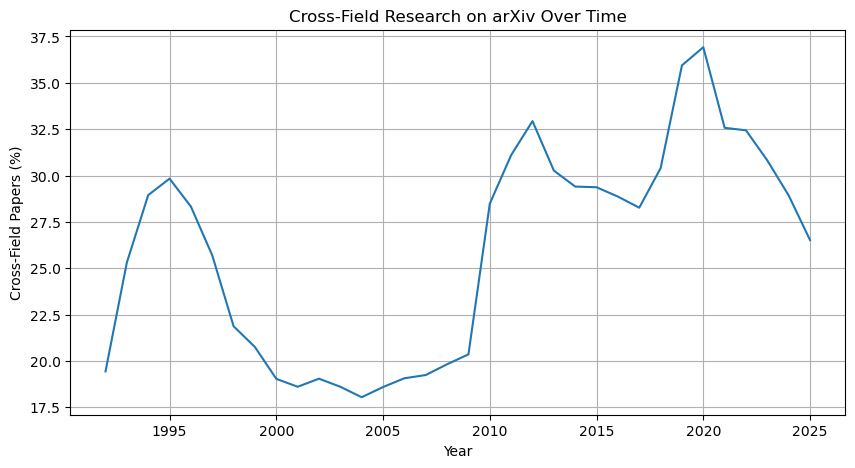

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    cross_field_year["submitted_year"],
    cross_field_year["cross_field_percent"]
)

plt.xlabel("Year")
plt.ylabel("Cross-Field Papers (%)")
plt.title("Cross-Field Research on arXiv Over Time")

plt.grid(True)
plt.show()

### Preliminary Interpretation

The percentage of cross-field papers does not increase steadily over time. The trend rises and falls across different periods. Cross-field activity was relatively high in the mid-1990s, decreased during the early 2000s, increased sharply after about 2009, and reached its highest level around 2020. Since then, the percentage has decreased somewhat.

This suggests that cross-field research has changed substantially over time, but the pattern is not a simple continuous increase.

**Limitation:** This measure uses arXiv category cross-listings as a proxy for cross-field collaboration. It shows that a paper spans multiple broad fields, but it does not prove that the individual authors themselves come from different research backgrounds. Changes in arXiv categories or classification practices over time may also affect the trend.

In [79]:
cross_field_year.tail(10)

,submitted_year,papers,cross_field_rate,average_fields,cross_field_percent
24,2016,113440,0.288646,1.376851,28.864598
25,2017,123781,0.282652,1.366938,28.265243
26,2018,140377,0.303960,1.387970,30.396005
27,2019,155917,0.359422,1.460457,35.942200
28,2020,178275,0.369199,1.471564,36.919927
29,2021,181599,0.325734,1.419562,32.573417
30,2022,185987,0.324383,1.417524,32.438289
31,2023,209223,0.308107,1.395736,30.810666
32,2024,243690,0.289257,1.370865,28.925684
33,2025,284162,0.265197,1.340302,26.519732


### Compare Cross-Field Collaboration Across Fields

In [80]:
# Get the broad primary field for each paper
analysis["primary_field"] = (
    analysis["primary_category"]
    .apply(broad_field)
)

# Find the largest fields based on number of papers
top_fields = (
    analysis["primary_field"]
    .value_counts()
    .head(6)
    .index
)

top_fields

Index(['cs', 'math', 'cond-mat', 'astro-ph', 'physics', 'hep-ph'], dtype='object', name='primary_field')

### Cross-Field Trends in the Largest Research Fields

In [81]:
field_year = (
    analysis[
        analysis["primary_field"].isin(top_fields)
    ]
    .groupby(["submitted_year", "primary_field"])
    .agg(
        papers=("paper_id", "size"),
        cross_field_rate=("cross_field", "mean")
    )
    .reset_index()
)

field_year["cross_field_percent"] = (
    field_year["cross_field_rate"] * 100
)

field_year.head(10)

,submitted_year,primary_field,papers,cross_field_rate,cross_field_percent
0,1992,astro-ph,59,0.389831,38.983051
1,1992,cond-mat,220,0.150000,15.000000
2,1992,cs,1,1.000000,100.000000
3,1992,hep-ph,755,0.144371,14.437086
4,1992,math,199,0.010050,1.005025
5,1993,astro-ph,490,0.177551,17.755102
6,1993,cond-mat,685,0.127007,12.700730
7,1993,cs,6,0.000000,0.000000
8,1993,hep-ph,1763,0.145207,14.520703
9,1993,math,221,0.054299,5.429864


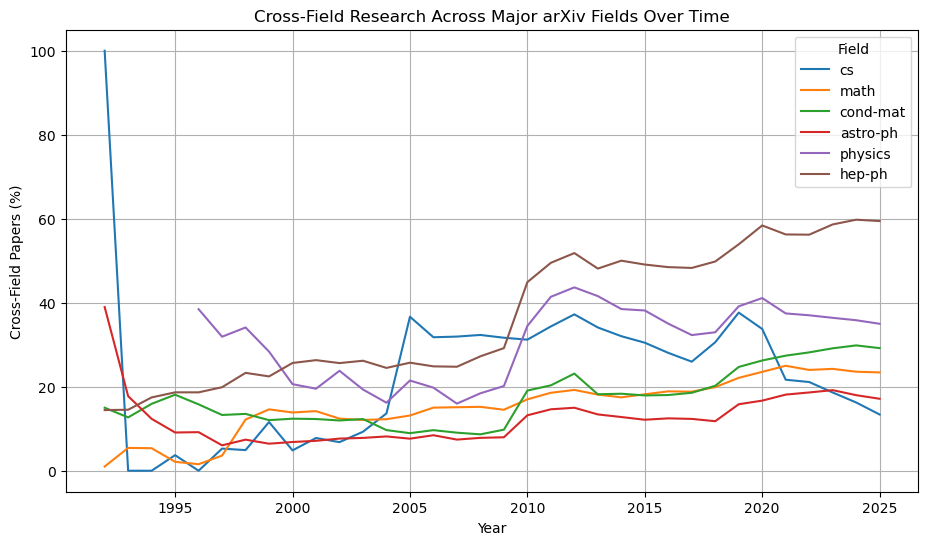

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 6))

for field in top_fields:
    temp = field_year[
        field_year["primary_field"] == field
    ]

    plt.plot(
        temp["submitted_year"],
        temp["cross_field_percent"],
        label=field
    )

plt.xlabel("Year")
plt.ylabel("Cross-Field Papers (%)")
plt.title("Cross-Field Research Across Major arXiv Fields Over Time")
plt.legend(title="Field")
plt.grid(True)
plt.show()

The very early CS value near 100% is suspicious. It probably does not mean almost every CS paper was cross-field then. More likely, there were only a very small number of CS papers in that early year, so a tiny sample is producing an extreme percentage. So the next step should be to check the number of papers behind each line.

### Check Sample Sizes Before Interpreting the Trends

In [83]:
field_year[
    ["submitted_year", "primary_field", "papers", "cross_field_percent"]
].head(30)

,submitted_year,primary_field,papers,cross_field_percent
0,1992,astro-ph,59,38.983051
1,1992,cond-mat,220,15.000000
2,1992,cs,1,100.000000
3,1992,hep-ph,755,14.437086
4,1992,math,199,1.005025
5,1993,astro-ph,490,17.755102
6,1993,cond-mat,685,12.700730
7,1993,cs,6,0.000000
8,1993,hep-ph,1763,14.520703
9,1993,math,221,5.429864


- cs in 1992 had only 1 paper, so if that one paper was cross-field, the rate becomes 100%.
- cs in 1993 had only 6 papers.
- cs in 1994 had only 15 papers.
- physics in 1996 had only 65 papers.
So those early percentages are unstable because the sample sizes are tiny.

 The next step is to filter out field-year combinations with fewer than 100 papers.

### Remove Very Small Field-Year Samples

In [84]:
field_year_filtered = field_year[
    field_year["papers"] >= 100
].copy()

field_year_filtered.head(20)

,submitted_year,primary_field,papers,cross_field_rate,cross_field_percent
1,1992,cond-mat,220,0.150000,15.000000
3,1992,hep-ph,755,0.144371,14.437086
4,1992,math,199,0.010050,1.005025
5,1993,astro-ph,490,0.177551,17.755102
6,1993,cond-mat,685,0.127007,12.700730
8,1993,hep-ph,1763,0.145207,14.520703
9,1993,math,221,0.054299,5.429864
10,1994,astro-ph,1028,0.123541,12.354086
11,1994,cond-mat,1325,0.159245,15.924528
13,1994,hep-ph,2498,0.174540,17.453963


lets remake the graph using the filtered data:

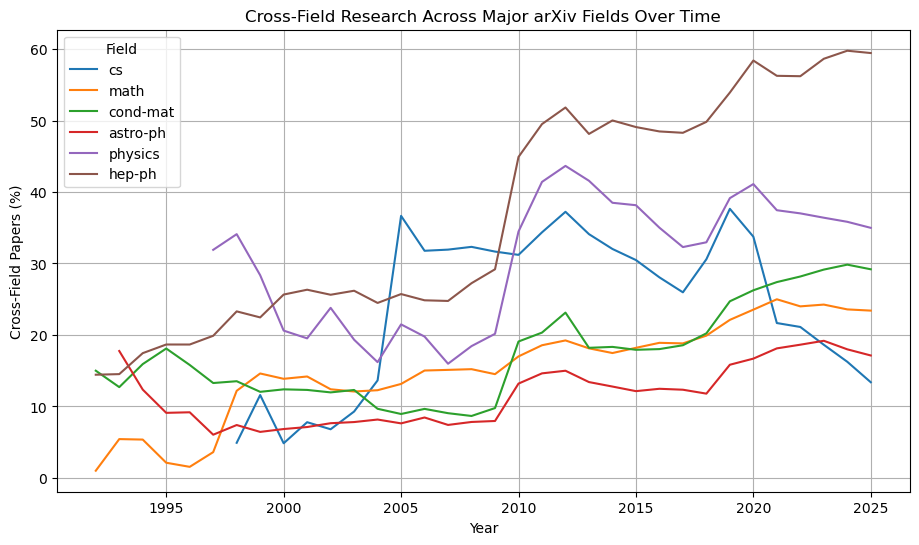

In [85]:
plt.figure(figsize=(11, 6))

for field in top_fields:
    temp = field_year_filtered[
        field_year_filtered["primary_field"] == field
    ]

    plt.plot(
        temp["submitted_year"],
        temp["cross_field_percent"],
        label=field
    )

plt.xlabel("Year")
plt.ylabel("Cross-Field Papers (%)")
plt.title("Cross-Field Research Across Major arXiv Fields Over Time")
plt.legend(title="Field")
plt.grid(True)

plt.show()

### Preliminary Field Comparison

Cross-field research shows different patterns across the major arXiv fields.

- `hep-ph` has the highest cross-field rate in recent years, increasing to roughly 60%.
- `physics` also shows a relatively high level of cross-field research, especially after 2010.
- `cond-mat` shows a more gradual increase over time.
- `math` increases more slowly and remains lower than several other fields.
- `cs` increased strongly during some periods but has declined in recent years.
- `astro-ph` remains comparatively lower in recent years.

Overall, the results suggest that cross-field research has not changed in the same way across all scientific fields.